In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == 'EDA':
    os.chdir('..')
    sys.path.append(os.getcwd())

print("Current Working Directory:", os.getcwd())

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

from processing_data.loading import load_lake_stations, load_rainfall_runoff, load_flood_masks

print("Environment is ready! All modules imported successfully.")

Current Working Directory: c:\Capstone Data Challenge\JBG060_ZHL_2026_Group19
Environment is ready! All modules imported successfully.


LAKE ANALYSIS

In [2]:

lake_data = load_lake_stations()

print("\nSuccessfully loaded lakes:", list(lake_data.keys()))

# Preview Lake Victoria
print("\n--- Lake Victoria Preview ---")
display(lake_data['victoria'].head())

Loading lake data for:  victoria
           mission  cycle  hour  minute  height_wrt_ref  height_err  \
date                                                                  
1992-10-07   TOPEX      2    17      34            0.46       0.042   
1992-10-17   TOPEX      3    15      33            0.47       0.042   
1992-10-27   TOPEX      4    13      31            0.51       0.042   
1992-11-06   TOPEX      5    11      30            0.51       0.042   
1992-11-16   TOPEX      6     9      28            0.49       0.042   

            backscatter_ku wet_tropo_corr iono_corr dry_tropo_corr  mode1  \
date                                                                        
1992-10-07           13.86            TMR       DOR            ERA      4   
1992-10-17           16.27            TMR       DOR            ERA      4   
1992-10-27           12.97            TMR       DOR            ERA      4   
1992-11-06           14.12            TMR       DOR            ERA      4   
1992-11

,mission,cycle,hour,minute,height_wrt_ref,height_err,backscatter_ku,wet_tropo_corr,iono_corr,dry_tropo_corr,mode1,mode2,ice_flag,height_egm2008,data_source_flag
date,,,,,,,,,,,,,,,
1992-10-07,TOPEX,2,17,34,0.46,0.042,13.86,TMR,DOR,ERA,4,0,0,1135.57,0
1992-10-17,TOPEX,3,15,33,0.47,0.042,16.27,TMR,DOR,ERA,4,0,0,1135.58,0
1992-10-27,TOPEX,4,13,31,0.51,0.042,12.97,TMR,DOR,ERA,4,0,0,1135.62,0
1992-11-06,TOPEX,5,11,30,0.51,0.042,14.12,TMR,DOR,ERA,4,0,0,1135.62,0
1992-11-16,TOPEX,6,9,28,0.49,0.042,14.81,TMR,DOR,ERA,4,0,0,1135.60,0


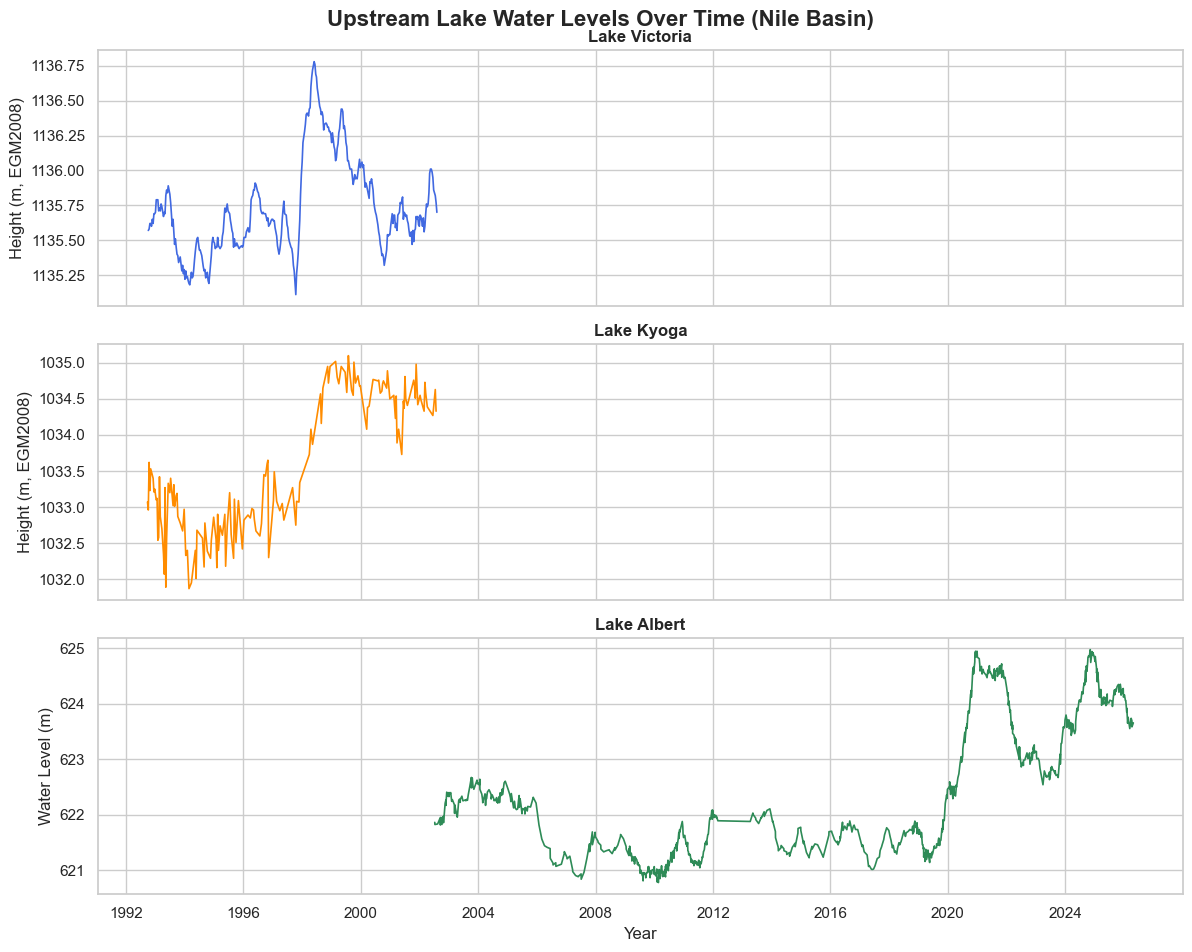

In [3]:
# Set up multi-panel time series plot for the three lakes
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Upstream Lake Water Levels Over Time (Nile Basin)', fontsize=16, fontweight='bold', y=0.95)

# 1. Lake Victoria
df_vic = lake_data['victoria']
axes[0].plot(df_vic.index, df_vic['height_egm2008'], color='royalblue', linewidth=1.2)
axes[0].set_title('Lake Victoria', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Height (m, EGM2008)')

# 2. Lake Kyoga
df_kyoga = lake_data['Kyoga']
axes[1].plot(df_kyoga.index, df_kyoga['height_egm2008'], color='darkorange', linewidth=1.2)
axes[1].set_title('Lake Kyoga', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Height (m, EGM2008)')

# 3. Lake Albert (closest to South Sudan border)
df_albert = lake_data['Albert']
axes[2].plot(df_albert.index, df_albert['water_level'], color='seagreen', linewidth=1.2)
axes[2].set_title('Lake Albert', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Water Level (m)')
axes[2].set_xlabel('Year', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.91)
plt.show()

2. ERA5 Rainfall and Runoff Analysis (Nile Basin)

In [4]:
years_to_load = np.array([2024])
ds_rain_runoff = load_rainfall_runoff(years_to_load)

print("\nDataset structure:")
print(ds_rain_runoff)

Daily total precipitation and runoff from ERA5 reanalysis loaded from dates 2024-01-01 to 2024-12-31
<xarray.Dataset> Size: 24MB
Dimensions:     (valid_time: 366, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01 ... 2024-12-31
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B 0
Data variables:
    tp          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
    ro          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:    

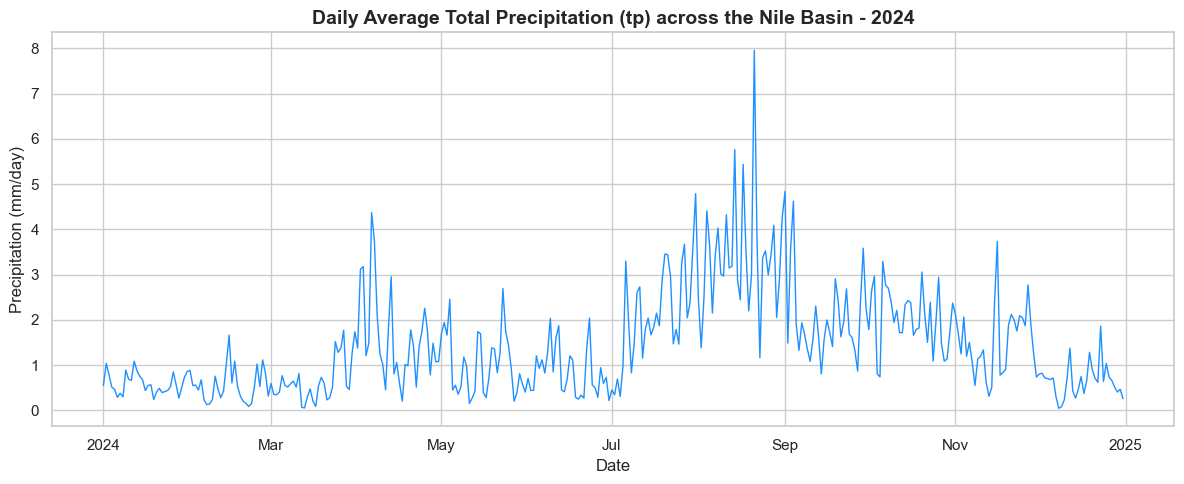

In [5]:
# Compute spatial mean across latitude and longitude to get a daily Nile Basin rainfall time series
daily_basin_rain = ds_rain_runoff['tp'].mean(dim=['latitude', 'longitude']) * 1000  # Convert meters to mm/day

# Plot daily rainfall time series for 2024
plt.figure(figsize=(12, 5))
daily_basin_rain.plot.line(x='valid_time', color='dodgerblue', linewidth=1)
plt.title('Daily Average Total Precipitation (tp) across the Nile Basin - 2024', fontsize=14, fontweight='bold')
plt.ylabel('Precipitation (mm/day)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

3. Lagged Analysis: Weather & Water Conditions Before vs. During Floods

1/4 Loading flood masks...
2/4 Loading ERA5 rainfall and runoff...
Daily total precipitation and runoff from ERA5 reanalysis loaded from dates 2024-01-01 to 2024-12-31
<xarray.Dataset> Size: 24MB
Dimensions:     (valid_time: 366, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01 ... 2024-12-31
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B 0
Data variables:
    tp          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
    ro          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             

,Rainfall (mm/day),Runoff (mm/day)
14 Days Before Flood,1.145344,0.363065
5 Days Before Flood,0.784423,0.288603
During Flood Day,0.596986,0.231648



--- Upstream Lake Water Levels Leading Up to Floods ---


,Lake Victoria (m),Lake Kyoga (m),Lake Albert (m)
14 Days Before Flood,NaN,NaN,624.525269
5 Days Before Flood,NaN,NaN,624.346313
During Flood Day,NaN,NaN,624.320129


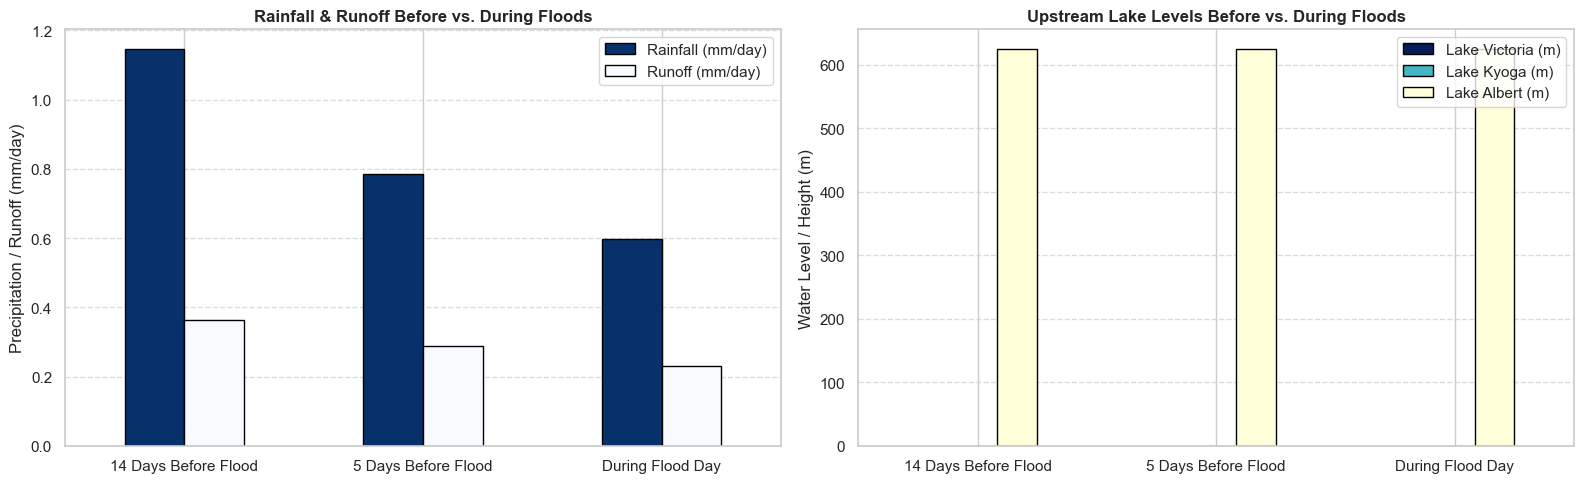

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD FLOOD MASKS (Hazard Observations)
# ==========================================
print("1/4 Loading flood masks...")
years_analysis = np.array([2024])
df_floods = load_flood_masks(years_analysis)

# Aggregate daily flooded pixel count across South Sudan
daily_flood_counts = df_floods.groupby('date').size().reset_index(name='flood_pixel_count')
daily_flood_counts['date'] = pd.to_datetime(daily_flood_counts['date'])
daily_flood_counts = daily_flood_counts.set_index('date').sort_index()

# ==========================================
# 2. LOAD RAINFALL & RUNOFF (ERA5 Drivers)
# ==========================================
print("2/4 Loading ERA5 rainfall and runoff...")
ds_weather = load_rainfall_runoff(years_analysis)

# Spatial mean across Nile Basin dimensions
daily_weather = ds_weather.mean(dim=['latitude', 'longitude']).to_dataframe().reset_index()
daily_weather['date'] = pd.to_datetime(daily_weather['valid_time'])

# Convert meters to mm/day on specific columns before setting index
daily_weather['rainfall_mm'] = daily_weather['tp'] * 1000
daily_weather['runoff_mm'] = daily_weather['ro'] * 1000
daily_weather = daily_weather.set_index('date').sort_index()

# ==========================================
# 3. LOAD ALL THREE LAKES (Upstream Storage)
# ==========================================
print("3/4 Loading upstream lake water levels (Victoria, Kyoga, Albert)...")
lake_data = load_lake_stations()

# Convert each lake to daily resolution using time-based interpolation
df_vic_daily = lake_data['victoria'][['height_egm2008']].resample('D').mean().interpolate(method='time')
df_kyoga_daily = lake_data['Kyoga'][['height_egm2008']].resample('D').mean().interpolate(method='time')
df_albert_daily = lake_data['Albert'][['water_level']].resample('D').mean().interpolate(method='time')

# ==========================================
# 4. MERGE INTO A SINGLE DAILY TIMELINE
# ==========================================
print("4/4 Building unified lag timeline...")
timeline_df = pd.DataFrame(index=daily_weather.index)

# Core daily metrics
timeline_df['rainfall_mm'] = daily_weather['rainfall_mm']
timeline_df['runoff_mm'] = daily_weather['runoff_mm']
timeline_df['flood_pixels'] = daily_flood_counts['flood_pixel_count'].reindex(timeline_df.index).fillna(0)

timeline_df['lake_victoria_m'] = df_vic_daily['height_egm2008'].reindex(timeline_df.index).ffill()
timeline_df['lake_kyoga_m'] = df_kyoga_daily['height_egm2008'].reindex(timeline_df.index).ffill()
timeline_df['lake_albert_m'] = df_albert_daily['water_level'].reindex(timeline_df.index).ffill()

# ==========================================
# 5. CREATE LAG FEATURES (14d, 5d, during)
# ==========================================
# Weather lags
timeline_df['Rain_14d_before'] = timeline_df['rainfall_mm'].shift(14)
timeline_df['Rain_5d_before'] = timeline_df['rainfall_mm'].shift(5)
timeline_df['Rain_during'] = timeline_df['rainfall_mm']

timeline_df['Runoff_14d_before'] = timeline_df['runoff_mm'].shift(14)
timeline_df['Runoff_5d_before'] = timeline_df['runoff_mm'].shift(5)
timeline_df['Runoff_during'] = timeline_df['runoff_mm']

# Lake level lags
for lake_col, label in [('lake_victoria_m', 'Vic'), ('lake_kyoga_m', 'Kyoga'), ('lake_albert_m', 'Albert')]:
    timeline_df[f'{label}_14d_before'] = timeline_df[lake_col].shift(14)
    timeline_df[f'{label}_5d_before'] = timeline_df[lake_col].shift(5)
    timeline_df[f'{label}_during'] = timeline_df[lake_col]

# ==========================================
# 6. FILTER SEVERE FLOOD SURGE DAYS
# ==========================================
threshold = timeline_df['flood_pixels'].quantile(0.90)
flood_event_days = timeline_df[timeline_df['flood_pixels'] > threshold]

print(f"\nAnalyzed {len(flood_event_days)} severe flood-surge days (Top 10% threshold).")

# ==========================================
# 7. SUMMARY TABLES
# ==========================================
summary_weather = pd.DataFrame({
    'Rainfall (mm/day)': [
        flood_event_days['Rain_14d_before'].mean(),
        flood_event_days['Rain_5d_before'].mean(),
        flood_event_days['Rain_during'].mean()
    ],
    'Runoff (mm/day)': [
        flood_event_days['Runoff_14d_before'].mean(),
        flood_event_days['Runoff_5d_before'].mean(),
        flood_event_days['Runoff_during'].mean()
    ]
}, index=['14 Days Before Flood', '5 Days Before Flood', 'During Flood Day'])

summary_lakes = pd.DataFrame({
    'Lake Victoria (m)': [
        flood_event_days['Vic_14d_before'].mean(),
        flood_event_days['Vic_5d_before'].mean(),
        flood_event_days['Vic_during'].mean()
    ],
    'Lake Kyoga (m)': [
        flood_event_days['Kyoga_14d_before'].mean(),
        flood_event_days['Kyoga_5d_before'].mean(),
        flood_event_days['Kyoga_during'].mean()
    ],
    'Lake Albert (m)': [
        flood_event_days['Albert_14d_before'].mean(),
        flood_event_days['Albert_5d_before'].mean(),
        flood_event_days['Albert_during'].mean()
    ]
}, index=['14 Days Before Flood', '5 Days Before Flood', 'During Flood Day'])

print("\n--- Weather Drivers (Rainfall & Runoff) Leading Up to Floods ---")
display(summary_weather)

print("\n--- Upstream Lake Water Levels Leading Up to Floods ---")
display(summary_lakes)

# ==========================================
# 8. VISUALIZATION
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Weather Drivers
summary_weather.plot(kind='bar', ax=axes[0], colormap='Blues_r', edgecolor='black')
axes[0].set_title('Rainfall & Runoff Before vs. During Floods', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Precipitation / Runoff (mm/day)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Upstream Lake Levels
summary_lakes.plot(kind='bar', ax=axes[1], colormap='YlGnBu_r', edgecolor='black')
axes[1].set_title('Upstream Lake Levels Before vs. During Floods', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Water Level / Height (m)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

4. The Annual Hydro-Graph (Monthly Seasonality)
Goal: Compare the average monthly cycle of rainfall upstream, water storage in the lakes, and flood surface area downstream to see how many months the water peak shifts as it travels down the basin.

Loading datasets...
Daily total precipitation and runoff from ERA5 reanalysis loaded from dates 2024-01-01 to 2024-12-31
<xarray.Dataset> Size: 24MB
Dimensions:     (valid_time: 366, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01 ... 2024-12-31
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B 0
Data variables:
    tp          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
    ro          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Foreca

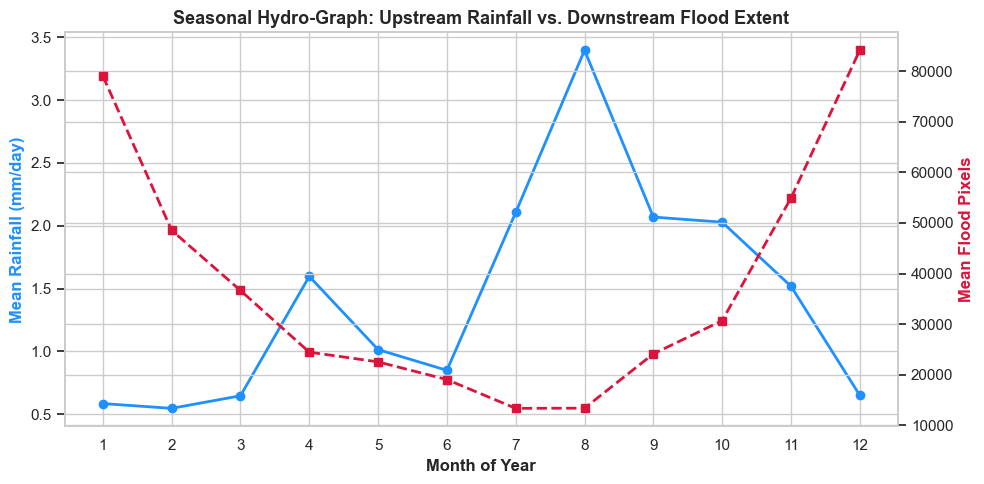

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load data for a specific multi-year window (e.g., 2024 or full historical overlapping period)
years = np.array([2024])

print("Loading datasets...")
df_floods = load_flood_masks(years)
ds_rain = load_rainfall_runoff(years)
lake_data = load_lake_stations()

# 2. Daily aggregation
daily_floods = (
    df_floods.groupby('date')
    .size()
    .reset_index(name='flood_pixels')
    .set_index('date')
)
daily_floods.index = pd.to_datetime(daily_floods.index)

daily_weather = (
    ds_rain.mean(dim=['latitude', 'longitude']).to_dataframe().reset_index()
)
daily_weather['date'] = pd.to_datetime(daily_weather['valid_time'])
daily_weather['rain_mm'] = daily_weather['tp'] * 1000
daily_weather = daily_weather.set_index('date')

df_albert = (
    lake_data['Albert'][['water_level']]
    .resample('D')
    .mean()
    .interpolate(method='time')
)

# 3. Combine and group by Month (1 to 12)
monthly_df = pd.DataFrame(index=daily_weather.index)
monthly_df['rainfall_mm'] = daily_weather['rain_mm']
monthly_df['flood_pixels'] = daily_floods['flood_pixels'].reindex(
    monthly_df.index, fill_value=0
)
monthly_df['lake_albert_m'] = df_albert['water_level'].reindex(
    monthly_df.index, method='ffill'
)

monthly_df['month'] = monthly_df.index.month

# Average metrics by calendar month
seasonal_profile = monthly_df.groupby('month').mean()

# 4. Plot Normalized Monthly Cycles
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Rainfall
ax1.plot(
    seasonal_profile.index,
    seasonal_profile['rainfall_mm'],
    color='dodgerblue',
    marker='o',
    linewidth=2,
    label='Rainfall (mm/day)',
)
ax1.set_xlabel('Month of Year', fontweight='bold')
ax1.set_ylabel('Mean Rainfall (mm/day)', color='dodgerblue', fontweight='bold')
ax1.set_xticks(range(1, 13))

# Plot Flood Extent on twin axis
ax2 = ax1.twinx()
ax2.plot(
    seasonal_profile.index,
    seasonal_profile['flood_pixels'],
    color='crimson',
    marker='s',
    linewidth=2,
    linestyle='--',
    label='Flood Extent (Pixels)',
)
ax2.set_ylabel('Mean Flood Pixels', color='crimson', fontweight='bold')

plt.title(
    'Seasonal Hydro-Graph: Upstream Rainfall vs. Downstream Flood Extent',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

5. Rolling Cumulative Rainfall vs. Flood Onset
Goal: Test whether floods in South Sudan are triggered by single-day heavy rainfall events or by 30-day / 60-day accumulated rainfall across the Nile Basin.

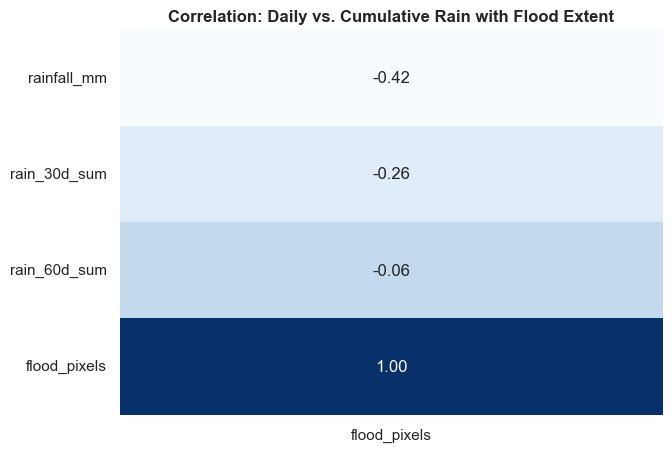

In [8]:
# Create rolling sums for accumulated basin precipitation
timeline_df['rain_30d_sum'] = timeline_df['rainfall_mm'].rolling(window=30).sum()
timeline_df['rain_60d_sum'] = timeline_df['rainfall_mm'].rolling(window=60).sum()

# Compute correlation matrix between rainfall accumulations and flood extent
corr_matrix = timeline_df[
    ['rainfall_mm', 'rain_30d_sum', 'rain_60d_sum', 'flood_pixels']
].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix[['flood_pixels']],
    annot=True,
    cmap='Blues',
    fmt='.2f',
    cbar=False,
)
plt.title(
    'Correlation: Daily vs. Cumulative Rain with Flood Extent',
    fontweight='bold',
)
plt.show()

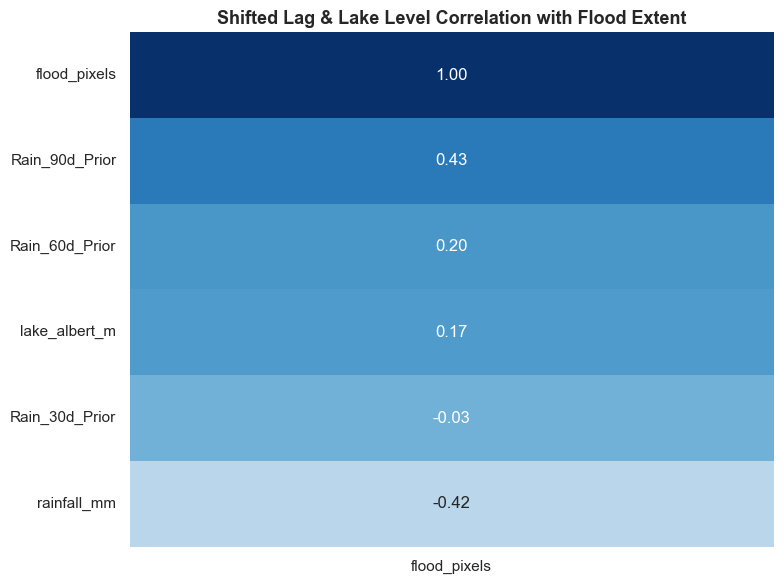

In [9]:
# 1. Create forward-shifted rainfall features (Rainfall that fell 30, 60, and 90 days PRIOR)
timeline_df['Rain_30d_Prior'] = timeline_df['rainfall_mm'].shift(30)
timeline_df['Rain_60d_Prior'] = timeline_df['rainfall_mm'].shift(60)
timeline_df['Rain_90d_Prior'] = timeline_df['rainfall_mm'].shift(90)

# 2. Select metrics including Lake Albert levels
corr_vars = [
    'rainfall_mm', 
    'Rain_30d_Prior', 
    'Rain_60d_Prior', 
    'Rain_90d_Prior', 
    'lake_albert_m', 
    'flood_pixels'
]

corr_matrix_shifted = timeline_df[corr_vars].corr()

# 3. Plot the heatmap focused on Flood Extent
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix_shifted[['flood_pixels']].sort_values(by='flood_pixels', ascending=False),
    annot=True, 
    cmap='Blues', 
    fmt='.2f', 
    cbar=False,
    vmin=-1, vmax=1
)
plt.title('Shifted Lag & Lake Level Correlation with Flood Extent', fontsize=13, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

6. Mapping Flood Frequency Across South Sudan

Loading spatial flood mask data...
Columns in df_floods: ['date', 'lat', 'lon', 'tile', 'flood_type']
Using spatial coordinate columns: 'lat' (lat) and 'lon' (lon)


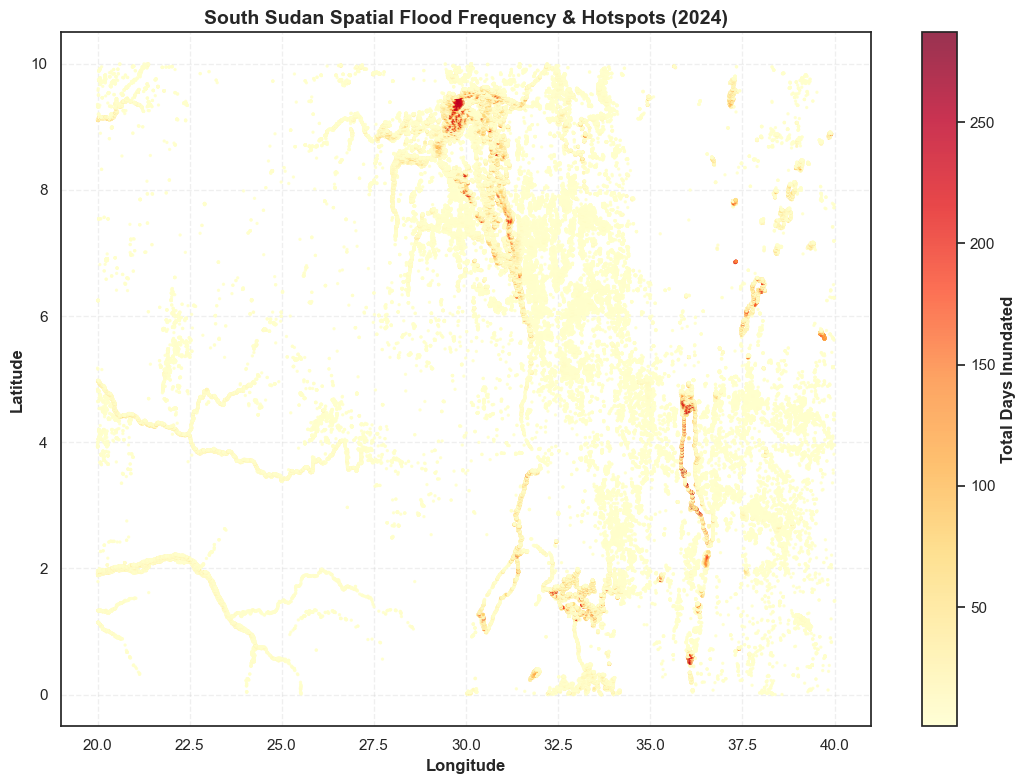

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load flood masks for analysis year
print("Loading spatial flood mask data...")
years_analysis = np.array([2024])
df_floods = load_flood_masks(years_analysis)

# Inspect column names to auto-detect coordinate naming
print("Columns in df_floods:", list(df_floods.columns))

cols_lower = {c.lower(): c for c in df_floods.columns}

if 'latitude' in cols_lower and 'longitude' in cols_lower:
    lat_col, lon_col = cols_lower['latitude'], cols_lower['longitude']
elif 'lat' in cols_lower and 'lon' in cols_lower:
    lat_col, lon_col = cols_lower['lat'], cols_lower['lon']
elif 'y' in cols_lower and 'x' in cols_lower:
    lat_col, lon_col = cols_lower['y'], cols_lower['x']
else:
    # Fallback to remaining non-date columns
    non_date = [c for c in df_floods.columns if c.lower() != 'date']
    lat_col, lon_col = non_date[0], non_date[1]

print(f"Using spatial coordinate columns: '{lat_col}' (lat) and '{lon_col}' (lon)")

# 2. Calculate flood occurrence frequency per spatial coordinate
spatial_flood_freq = (
    df_floods.groupby([lat_col, lon_col])
    .size()
    .reset_index(name='flood_days_count')
)

# 3. Plot the Spatial Flood Density Map
plt.figure(figsize=(11, 8))
sns.set_theme(style="white")

sc = plt.scatter(
    spatial_flood_freq[lon_col],
    spatial_flood_freq[lat_col],
    c=spatial_flood_freq['flood_days_count'],
    cmap='YlOrRd',
    s=2,
    alpha=0.8
)

cbar = plt.colorbar(sc)
cbar.set_label('Total Days Inundated', fontweight='bold')

plt.title('South Sudan Spatial Flood Frequency & Hotspots (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Longitude', fontweight='bold')
plt.ylabel('Latitude', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
import folium
from folium.plugins import HeatMap

# 1. Load flood masks for analysis year
print("Loading spatial flood mask data...")
years_analysis = np.array([2024])
df_floods = load_flood_masks(years_analysis)

# 2. Auto-detect spatial coordinate columns
cols_lower = {c.lower(): c for c in df_floods.columns}
if 'latitude' in cols_lower and 'longitude' in cols_lower:
    lat_col, lon_col = cols_lower['latitude'], cols_lower['longitude']
elif 'lat' in cols_lower and 'lon' in cols_lower:
    lat_col, lon_col = cols_lower['lat'], cols_lower['lon']
elif 'y' in cols_lower and 'x' in cols_lower:
    lat_col, lon_col = cols_lower['y'], cols_lower['x']
else:
    non_date = [c for c in df_floods.columns if c.lower() != 'date']
    lat_col, lon_col = non_date[0], non_date[1]

# 3. Calculate flood occurrence frequency per coordinate
spatial_flood_freq = (
    df_floods.groupby([lat_col, lon_col])
    .size()
    .reset_index(name='flood_days_count')
)

# 4. Create Interactive Folium Map centered on South Sudan
# OpenStreetMap tiles show towns, highways, and river names
m = folium.Map(location=[7.5, 30.0], zoom_start=6, tiles='OpenStreetMap')

# Prepare [latitude, longitude, weight] points
heat_data = [
    [row[lat_col], row[lon_col], float(row['flood_days_count'])] 
    for _, row in spatial_flood_freq.iterrows()
]

# Add HeatMap layer
HeatMap(
    heat_data,
    radius=12,
    blur=15,
    max_zoom=10,
    gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'yellow', 1.0: 'red'}
).add_to(m)


# Save the folium map to an HTML file in project folder
m.save("south_sudan_flood_map.html")
print("Map saved! Double-click 'south_sudan_flood_map.html' in your VS Code file explorer to open it in your browser.")

Loading spatial flood mask data...
Map saved! Double-click 'south_sudan_flood_map.html' in your VS Code file explorer to open it in your browser.


EXTRA: Looking at Missing data

In [14]:
import pandas as pd
import numpy as np
import xarray as xr

# Ensure all 3 datasets are loaded for your target years
# historical_years = np.arange(2000, 2025)
# df_floods = load_flood_masks(historical_years)
# ds_rain = load_rainfall_runoff(historical_years)
# lake_data = load_lake_stations()

def summarize_missing_data(df_floods, ds_rain, lake_data):
    print("=========================================================")
    print("        1. CHECKING FOR NaN / NULL VALUES IN RECORDS     ")
    print("=========================================================\n")
    
    # 1A. Flood Masks (DataFrame)
    print("--- 1. Flood Masks (MODIS/VIIRS) ---")
    flood_nan = df_floods.isna().sum()
    flood_nan_pct = (flood_nan / len(df_floods) * 100).round(2)
    flood_summary = pd.DataFrame({'Missing_Count': flood_nan, 'Percentage (%)': flood_nan_pct})
    display(flood_summary)
    
    # 1B. Rainfall & Runoff (ERA5 xarray.Dataset)
    print("\n--- 2. Rainfall & Runoff (ERA5) ---")
    rain_nan_dict = {}
    total_grid_points = ds_rain['valid_time'].size * ds_rain['latitude'].size * ds_rain['longitude'].size
    for var in ds_rain.data_vars:
        null_count = int(ds_rain[var].isnull().sum().values)
        rain_nan_dict[var] = {
            'Missing_Count': null_count,
            'Percentage (%)': round((null_count / total_grid_points) * 100, 2)
        }
    rain_summary = pd.DataFrame(rain_nan_dict).T
    display(rain_summary)
    
    # 1C. Upstream Lakes (Dictionary of DataFrames)
    print("\n--- 3. Upstream Lakes (Victoria, Kyoga, Albert) ---")
    for lake_name, df_lake in lake_data.items():
        print(f"\n> Lake {lake_name.capitalize()}:")
        lake_nan = df_lake.isna().sum()
        lake_nan_pct = (lake_nan / len(df_lake) * 100).round(2)
        lake_summary = pd.DataFrame({'Missing_Count': lake_nan, 'Percentage (%)': lake_nan_pct})
        # Filter to display columns with missing data or display main height columns
        display(lake_summary[lake_summary['Missing_Count'] > 0] if (lake_summary['Missing_Count'] > 0).any() else "No NaN values found in existing records.")

    print("\n=========================================================")
    print("        2. CHECKING FOR MISSING CALENDAR DATES (GAPS)    ")
    print("=========================================================\n")
    
    def get_date_gap_df(dates_seq, dataset_label):
        unique_dates = pd.DatetimeIndex(dates_seq).normalize().unique()
        start_date, end_date = unique_dates.min(), unique_dates.max()
        
        full_calendar = pd.date_range(start=start_date, end=end_date, freq='D')
        missing_dates = full_calendar.difference(unique_dates)
        
        total_days = len(full_calendar)
        recorded_days = len(unique_dates)
        missing_count = len(missing_dates)
        pct_missing = round((missing_count / total_days) * 100, 2)
        
        print(f"Dataset: {dataset_label}")
        print(f"  • Date Span: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
        print(f"  • Total Expected Calendar Days: {total_days}")
        print(f"  • Days with Records: {recorded_days}")
        print(f"  • Missing Days (Gaps): {missing_count} ({pct_missing}%)\n")
        
        return pd.DataFrame({'Missing_Date': missing_dates, 'Dataset': dataset_label})

    # Date gap checks
    missing_dates_floods = get_date_gap_df(df_floods['date'], "Flood Masks")
    missing_dates_rain = get_date_gap_df(ds_rain['valid_time'].values, "ERA5 Rainfall/Runoff")
    
    missing_dates_lakes = {}
    for lake_name, df_lake in lake_data.items():
        missing_dates_lakes[lake_name] = get_date_gap_df(df_lake.index, f"Lake {lake_name.capitalize()}")

    return {
        'missing_dates_floods': missing_dates_floods,
        'missing_dates_rain': missing_dates_rain,
        'missing_dates_lakes': missing_dates_lakes
    }

# Run the missing data audit and save gap DataFrames to variable
gap_dataframes = summarize_missing_data(df_floods, ds_rain, lake_data)

        1. CHECKING FOR NaN / NULL VALUES IN RECORDS     

--- 1. Flood Masks (MODIS/VIIRS) ---


,Missing_Count,Percentage (%)
date,0,0.0
lat,0,0.0
lon,0,0.0
tile,0,0.0
flood_type,0,0.0



--- 2. Rainfall & Runoff (ERA5) ---


,Missing_Count,Percentage (%)
tp,0.0,0.0
ro,0.0,0.0



--- 3. Upstream Lakes (Victoria, Kyoga, Albert) ---

> Lake Victoria:


...


> Lake Kyoga:


'No NaN values found in existing records.'


> Lake Albert:


'No NaN values found in existing records.'


        2. CHECKING FOR MISSING CALENDAR DATES (GAPS)    

Dataset: Flood Masks
  • Date Span: 2000-02-28 to 2024-12-31
  • Total Expected Calendar Days: 9074
  • Days with Records: 8885
  • Missing Days (Gaps): 189 (2.08%)

Dataset: ERA5 Rainfall/Runoff
  • Date Span: 2000-01-01 to 2024-12-31
  • Total Expected Calendar Days: 9132
  • Days with Records: 9132
  • Missing Days (Gaps): 0 (0.0%)

Dataset: Lake Victoria
  • Date Span: 1992-10-07 to 2002-08-06
  • Total Expected Calendar Days: 3591
  • Days with Records: 329
  • Missing Days (Gaps): 3262 (90.84%)

Dataset: Lake Kyoga
  • Date Span: 1992-09-27 to 2002-07-27
  • Total Expected Calendar Days: 3591
  • Days with Records: 156
  • Missing Days (Gaps): 3435 (95.66%)

Dataset: Lake Albert
  • Date Span: 2002-07-10 to 2026-04-25
  • Total Expected Calendar Days: 8691
  • Days with Records: 796
  • Missing Days (Gaps): 7895 (90.84%)

